# Exploración de Datos Inicial

### Decisiones de Arquitectura
- **Poetry**: Utilizamos Poetry en este repositorio para la gestión de dependencias y empaquetado porque ya estoy acostumbrado a su flujo de trabajo, el cual es más robusto y ordenado que un `requirements.txt` tradicional.
- **FastAPI**: Elegimos FastAPI para desarrollar la API porque es el mejor y más eficiente para esta demo, ofreciendo excelente rendimiento y documentación automática (Swagger) sin configuraciones complejas.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Configuraciones básicas para gráficos
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

### Carga y visualización de los datos

**Justificación de limpieza:** Descartamos directamente la última columna (`value`) del archivo porque no contiene valores útiles (viene completamente vacía/sin datos de valor para el análisis). De esta forma evitamos ruido innecesario en el dataset.

In [ ]:
column_names = ['user_id', 'game_title', 'behavior', 'hours', 'value']
df = pd.read_csv('../dataset-videojuegos.csv', names=column_names)

# Limpieza: eliminar la columna 'value' ya que no tiene datos útiles
df = df.drop(columns=['value'])

print(f"Dimensiones del dataset: {df.shape}")
df.head()

In [ ]:
# Ver información general de los tipos de datos y valores nulos
df.info()

In [ ]:
# Resumen estadístico de variables numéricas
df.describe()

### Distribución de Comportamientos (Compra vs Juego)

In [ ]:
behavior_counts = df['behavior'].value_counts()
plt.figure(figsize=(8, 5))
sns.barplot(x=behavior_counts.index, y=behavior_counts.values, palette='viridis')
plt.title('Distribución de Comportamientos (Compra vs Juego)')
plt.ylabel('Cantidad')
plt.show()

### Top 10 Juegos: Populares, Jugados y Comprados

A continuación, analizaremos los 10 juegos más populares (mayor cantidad de interacciones totales), los 10 más jugados (mayor cantidad de horas acumuladas) y los 10 más comprados (mayor cantidad de compras).

In [ ]:
# Top 10 más comprados
top_purchased = df[df['behavior'] == 'purchase']['game_title'].value_counts().head(10)

# Top 10 más jugados (por horas totales)
top_played_hours = df[df['behavior'] == 'play'].groupby('game_title')['hours'].sum().sort_values(ascending=False).head(10)

# Top 10 más populares (por número de interacciones totales)
top_popular = df['game_title'].value_counts().head(10)

# Graficamos
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

# Populares
sns.barplot(x=top_popular.values, y=top_popular.index, ax=axes[0], palette='Blues_r', hue=top_popular.index, legend=False)
axes[0].set_title('Top 10 Juegos Más Populares (Interacciones Totales)')
axes[0].set_xlabel('Cantidad de Interacciones')
axes[0].set_ylabel('')

# Jugados
sns.barplot(x=top_played_hours.values, y=top_played_hours.index, ax=axes[1], palette='Greens_r', hue=top_played_hours.index, legend=False)
axes[1].set_title('Top 10 Juegos Más Jugados (Horas Totales)')
axes[1].set_xlabel('Horas Jugadas')
axes[1].set_ylabel('')

# Comprados
sns.barplot(x=top_purchased.values, y=top_purchased.index, ax=axes[2], palette='Oranges_r', hue=top_purchased.index, legend=False)
axes[2].set_title('Top 10 Juegos Más Comprados')
axes[2].set_xlabel('Cantidad de Compras')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

### Preprocesamiento de Datos para el Modelo

A continuación, realizaremos un filtrado para evitar el ruido generado por usuarios y juegos con muy pocas interacciones. Además, calcularemos un `score` (puntuación) implícito que combina las compras y las horas jugadas.

In [ ]:
print("Procesando datos para el modelo...")
# Filtramos usuarios y juegos con muy pocas interacciones para evitar ruido
user_counts = df['user_id'].value_counts()
game_counts = df['game_title'].value_counts()

valid_users = user_counts[user_counts > 2].index
valid_games = game_counts[game_counts > 5].index

df_filtered = df[(df['user_id'].isin(valid_users)) & (df['game_title'].isin(valid_games))].copy()

def calculate_score(row):
    if row['behavior'] == 'purchase':
        return 0.1
    else:
        return 1.0 + np.log1p(row['hours'])

df_filtered['score'] = df_filtered.apply(calculate_score, axis=1)

# Nos quedamos con el máximo score por usuario y juego
df_grouped = df_filtered.groupby(['user_id', 'game_title'])['score'].max().reset_index()
df_grouped.head()

### Cold Start: Ranking para Usuarios Nuevos

Para los usuarios nuevos que no tienen historial de interacciones, utilizaremos un ranking general de popularidad. A continuación extraemos los 5 juegos más populares y los guardamos para poder utilizarlos posteriormente en la API de recomendaciones.

In [ ]:
# Obtenemos los 5 juegos más populares (basado en interacciones totales)
top_5_cold_start = df['game_title'].value_counts().head(5).index.tolist()

print("Top 5 juegos para Cold Start (Usuarios Nuevos):")
for i, game in enumerate(top_5_cold_start, 1):
    print(f"{i}. {game}")

# Guardamos este ranking para que la API lo consuma luego
import json
with open('../top_5_cold_start.json', 'w', encoding='utf-8') as f:
    json.dump(top_5_cold_start, f, ensure_ascii=False, indent=4)

print("\nArchivo 'top_5_cold_start.json' guardado exitosamente.")

### 3.2 Historial de Usuarios
Guardamos un diccionario con los juegos que ha jugado cada usuario para no recomendarlos nuevamente y para usar como semilla de recomendación.

In [ ]:
user_history = df_grouped.groupby('user_id')['game_title'].apply(list).to_dict()

### 3.3 Matriz de Similitud Item-Item (Filtrado Colaborativo)
Construimos una matriz pivotada donde las filas son ítems (juegos) y las columnas usuarios. Luego calculamos la similitud coseno entre ítems.

**Justificación de usar Similitud Coseno:**
Elegimos la similitud del coseno porque es la métrica ideal para matrices dispersas (con muchos ceros) típicas de sistemas de recomendación. Al medir el *ángulo* entre vectores y no su longitud, evita que la inmensa popularidad de algunos juegos sesgue los resultados, logrando identificar similitudes entre juegos basándose en la proporción de usuarios compartidos y no en la cantidad absoluta de interacciones.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

print("Calculando matriz de similitudes (Cosine Similarity)...")
pivot = df_grouped.pivot(index='user_id', columns='game_title', values='score').fillna(0)
item_matrix = pivot.T

similarity_matrix = cosine_similarity(item_matrix)
similarity_df = pd.DataFrame(similarity_matrix, index=item_matrix.index, columns=item_matrix.index)

print(f"Dimensiones de la matriz de similitud: {similarity_df.shape}")

## 4. Generación de Artefactos del Modelo
Guardamos la matriz de similitud, el historial de usuarios y el ranking de cold start para que la API pueda consumirlos sin recalcular nada.

In [ ]:
import os
import pickle
import json

os.makedirs('../app/model_artifacts', exist_ok=True)

# 1. Matriz de Similitud
similarity_df.to_pickle('../app/model_artifacts/similarity_matrix.pkl')

# 2. Historial de usuarios
# Convertimos las claves a int nativos de Python para evitar errores de serialización JSON con np.int64
user_history_clean = {int(k): v for k, v in user_history.items()}
with open('../app/model_artifacts/user_history.json', 'w', encoding='utf-8') as f:
    json.dump(user_history_clean, f, ensure_ascii=False)

# 3. Top 5 Cold Start
top_5_cold_start = df['game_title'].value_counts().head(5).index.tolist()
with open('../app/model_artifacts/top_5_cold_start.json', 'w', encoding='utf-8') as f:
    json.dump(top_5_cold_start, f, ensure_ascii=False, indent=4)

print("Artefactos guardados en '../app/model_artifacts/'")

## 5. Validación: Comparación de Historial vs Recomendaciones
Analizamos los juegos de usuarios de ejemplo para visualizar qué juegan frente a lo que el modelo recomienda, constatando que no se recomiendan los juegos que ya tienen.

/var/folders/2l/2mh1yy1n5298hy47s1z13_2h0000gn/T/ipykernel_55689/4112472499.py:41: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  plt.tight_layout()
/Users/kevin/Documents/tp-ciencia-de-datos-2026/tp-ciencia-de-datos-2026/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


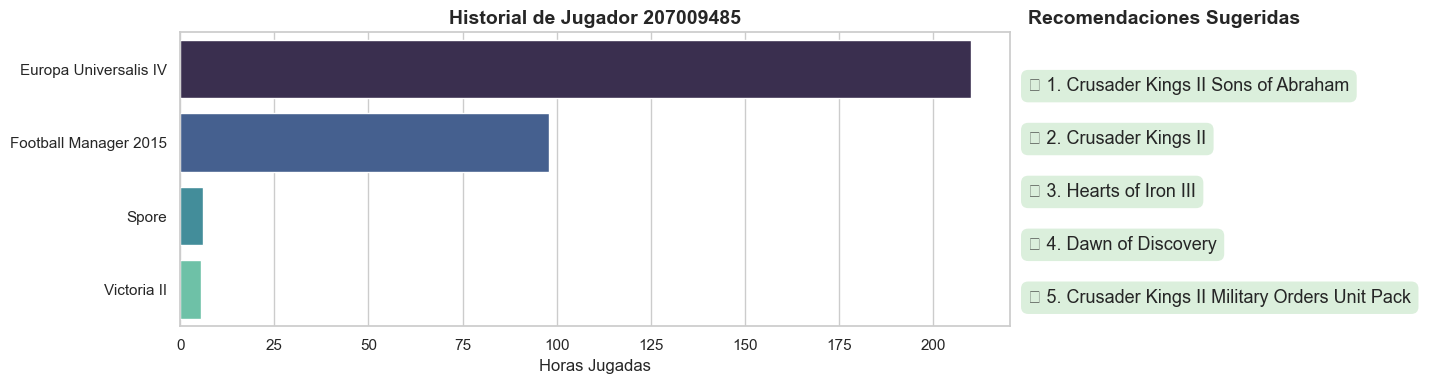

/var/folders/2l/2mh1yy1n5298hy47s1z13_2h0000gn/T/ipykernel_55689/4112472499.py:41: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  plt.tight_layout()
/Users/kevin/Documents/tp-ciencia-de-datos-2026/tp-ciencia-de-datos-2026/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


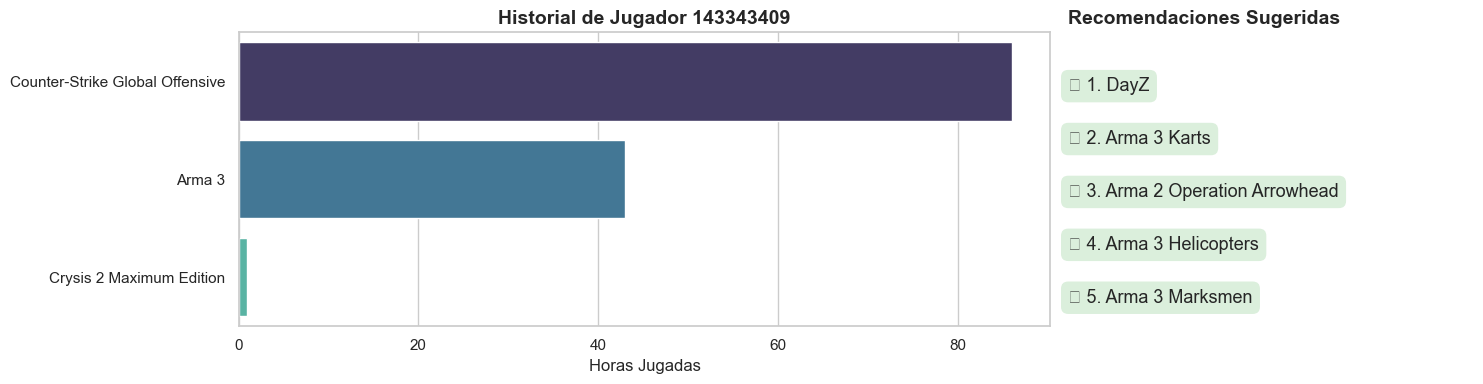

/var/folders/2l/2mh1yy1n5298hy47s1z13_2h0000gn/T/ipykernel_55689/4112472499.py:41: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  plt.tight_layout()
/Users/kevin/Documents/tp-ciencia-de-datos-2026/tp-ciencia-de-datos-2026/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


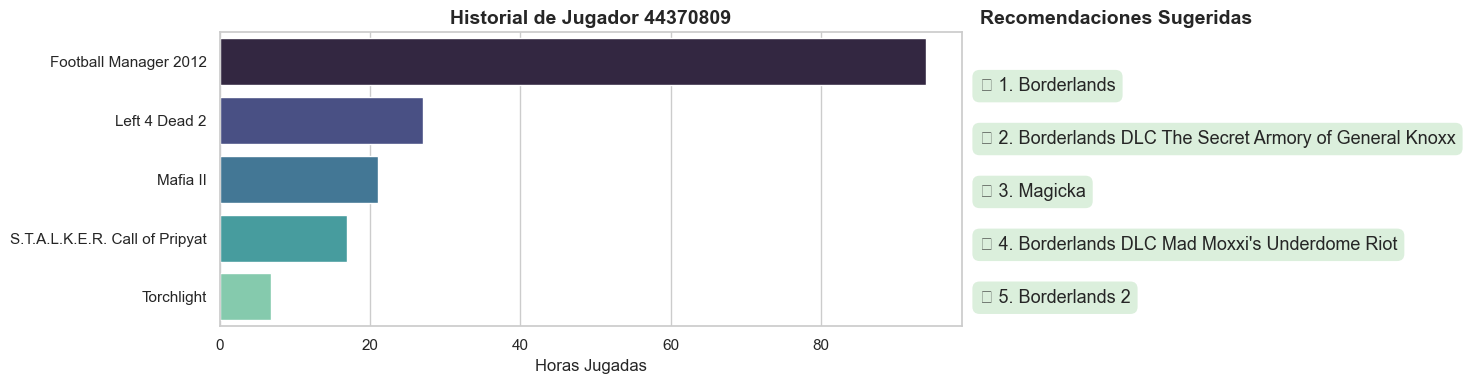

In [ ]:
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.append(os.path.abspath('..'))
from app.recommender import RecommenderEngine

# Inicializamos el motor usando los artefactos recién guardados
recommender = RecommenderEngine(model_dir='../app/model_artifacts')

test_users = [207009485, 143343409, 44370809]

for user in test_users:
    user_data = df[(df['user_id'] == user) & (df['behavior'] == 'play')].sort_values(by='hours', ascending=False).head(5)
    recs = recommender.get_recommendations(user, k=5)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4), gridspec_kw={'width_ratios': [2, 1]})
    
    # Left subplot: Historial
    if not user_data.empty:
        sns.barplot(data=user_data, x='hours', y='game_title', ax=ax1, palette='mako', hue='game_title', legend=False)
        ax1.set_title(f'Historial de Jugador {user}', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Horas Jugadas')
        ax1.set_ylabel('')
    else:
        ax1.text(0.5, 0.5, 'Sin historial previo (Usuario Nuevo)', ha='center', va='center', fontsize=12)
        ax1.set_title(f'Historial de Jugador {user}', fontsize=14, fontweight='bold')
        ax1.axis('off')
        
    # Right subplot: Recomendaciones
    ax2.axis('off')
    ax2.set_title('Recomendaciones Sugeridas', fontsize=14, fontweight='bold', loc='left')
    
    # Imprimimos las recomendaciones como un texto estilizado
    y_pos = 0.8
    for i, rec in enumerate(recs, 1):
        ax2.text(0.0, y_pos, f"{i}. {rec}", fontsize=13, 
                 bbox=dict(facecolor='#4CAF50', alpha=0.2, edgecolor='none', boxstyle='round,pad=0.4'))
        y_pos -= 0.18
                 
    plt.tight_layout()
    plt.show()


Al observar los resultados, confirmamos que el recomendador excluye exitosamente los juegos que el usuario ya posee y sugiere títulos afines basados en la matriz de similitud o popularidad.